In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

print("✅ All libraries imported")

✅ All libraries imported


In [4]:
df = pd.read_csv('School_dropout_Dataset.csv')

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

print("\nClass balance:")
print("  Stayed      (0) :", (df['Dropped_out']==0).sum())
print("  Dropped Out (1) :", (df['Dropped_out']==1).sum())
print("  Dropout rate    :", f"{df['Dropped_out'].mean()*100:.1f}%")

print("\nFirst 3 rows:")
display(df.head(3))

Rows    : 301
Columns : 16

Class balance:
  Stayed      (0) : 104
  Dropped Out (1) : 197
  Dropout rate    : 65.4%

First 3 rows:


,Child_Age,Child_Gender,Lack_of_School_Material,Lack _of _School_Fees,Job_opportunity,Pregnancy,Family _conflicts,Drug_abuse,Lack_of_motivation,Illness,Absenteism,Bad_Discipline,Performance,Social_activity,Year_of_Study,Dropped_out
0,17 - 19,Male,1,0,0,0,0,0,0,0,0,0,41-50,NaN,Upper Secondary,1
1,13-Jun,Male,1,0,0,0,0,0,0,0,1,1,41-50,Other,Primary,1
2,13-Jun,Male,1,0,0,0,0,0,0,0,1,1,71-100,Other,Primary,0


In [5]:
# Child_Age: text → number
df['Child_Age'] = df['Child_Age'].map({
    '13-Jun':  0,
    '14 - 16': 1,
    '17 - 19': 2,
    '20 - 21': 3
})

# Child_Gender: text → number
df['Child_Gender'] = df['Child_Gender'].map({
    'Male':   0,
    'Female': 1
})

# Performance: marks range → number
df['Performance'] = df['Performance'].map({
    '0-40':   0,
    '41-50':  1,
    '51-60':  2,
    '61-70':  3,
    '71-100': 4
})

# Year_of_Study: text → number
# (original has double spaces like 'Upper  Secondary' — fixed with .split())
df['Year_of_Study'] = df['Year_of_Study'].apply(
    lambda x: ' '.join(x.split())
).map({
    'Primary':         0,
    'Lower Secondary': 1,
    'Upper Secondary': 2
})

# Social_activity: NaN means no activity
# Split into 4 separate 0/1 columns (one-hot)
df['Social_activity'] = df['Social_activity'].fillna('None')
df['Social_activity_Dance'] = (df['Social_activity'] == 'Dance').astype(int)
df['Social_activity_None']  = (df['Social_activity'] == 'None').astype(int)
df['Social_activity_Other'] = (df['Social_activity'] == 'Other').astype(int)
df['Social_activity_Sport'] = (df['Social_activity'] == 'Sport').astype(int)
df.drop(columns=['Social_activity'], inplace=True)

# Fix column names that have spaces
df.rename(columns={
    'Lack _of _School_Fees': 'Lack_of_School_Fees',
    'Family _conflicts':     'Family_conflicts'
}, inplace=True)

# Check
print("Shape  :", df.shape)
print("Nulls  :", df.isnull().sum().sum(), " ← must be 0")
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows after encoding:")
display(df.head(3))

Shape  : (301, 19)
Nulls  : 0  ← must be 0

Columns: ['Child_Age', 'Child_Gender', 'Lack_of_School_Material', 'Lack_of_School_Fees', 'Job_opportunity', 'Pregnancy', 'Family_conflicts', 'Drug_abuse', 'Lack_of_motivation', 'Illness', 'Absenteism', 'Bad_Discipline', 'Performance', 'Year_of_Study', 'Dropped_out', 'Social_activity_Dance', 'Social_activity_None', 'Social_activity_Other', 'Social_activity_Sport']

First 3 rows after encoding:


,Child_Age,Child_Gender,Lack_of_School_Material,Lack_of_School_Fees,Job_opportunity,Pregnancy,Family_conflicts,Drug_abuse,Lack_of_motivation,Illness,Absenteism,Bad_Discipline,Performance,Year_of_Study,Dropped_out,Social_activity_Dance,Social_activity_None,Social_activity_Other,Social_activity_Sport
0,2,0,1,0,0,0,0,0,0,0,0,0,1,2,1,0,1,0,0
1,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,1,0
2,0,0,1,0,0,0,0,0,0,0,1,1,4,0,0,0,0,1,0


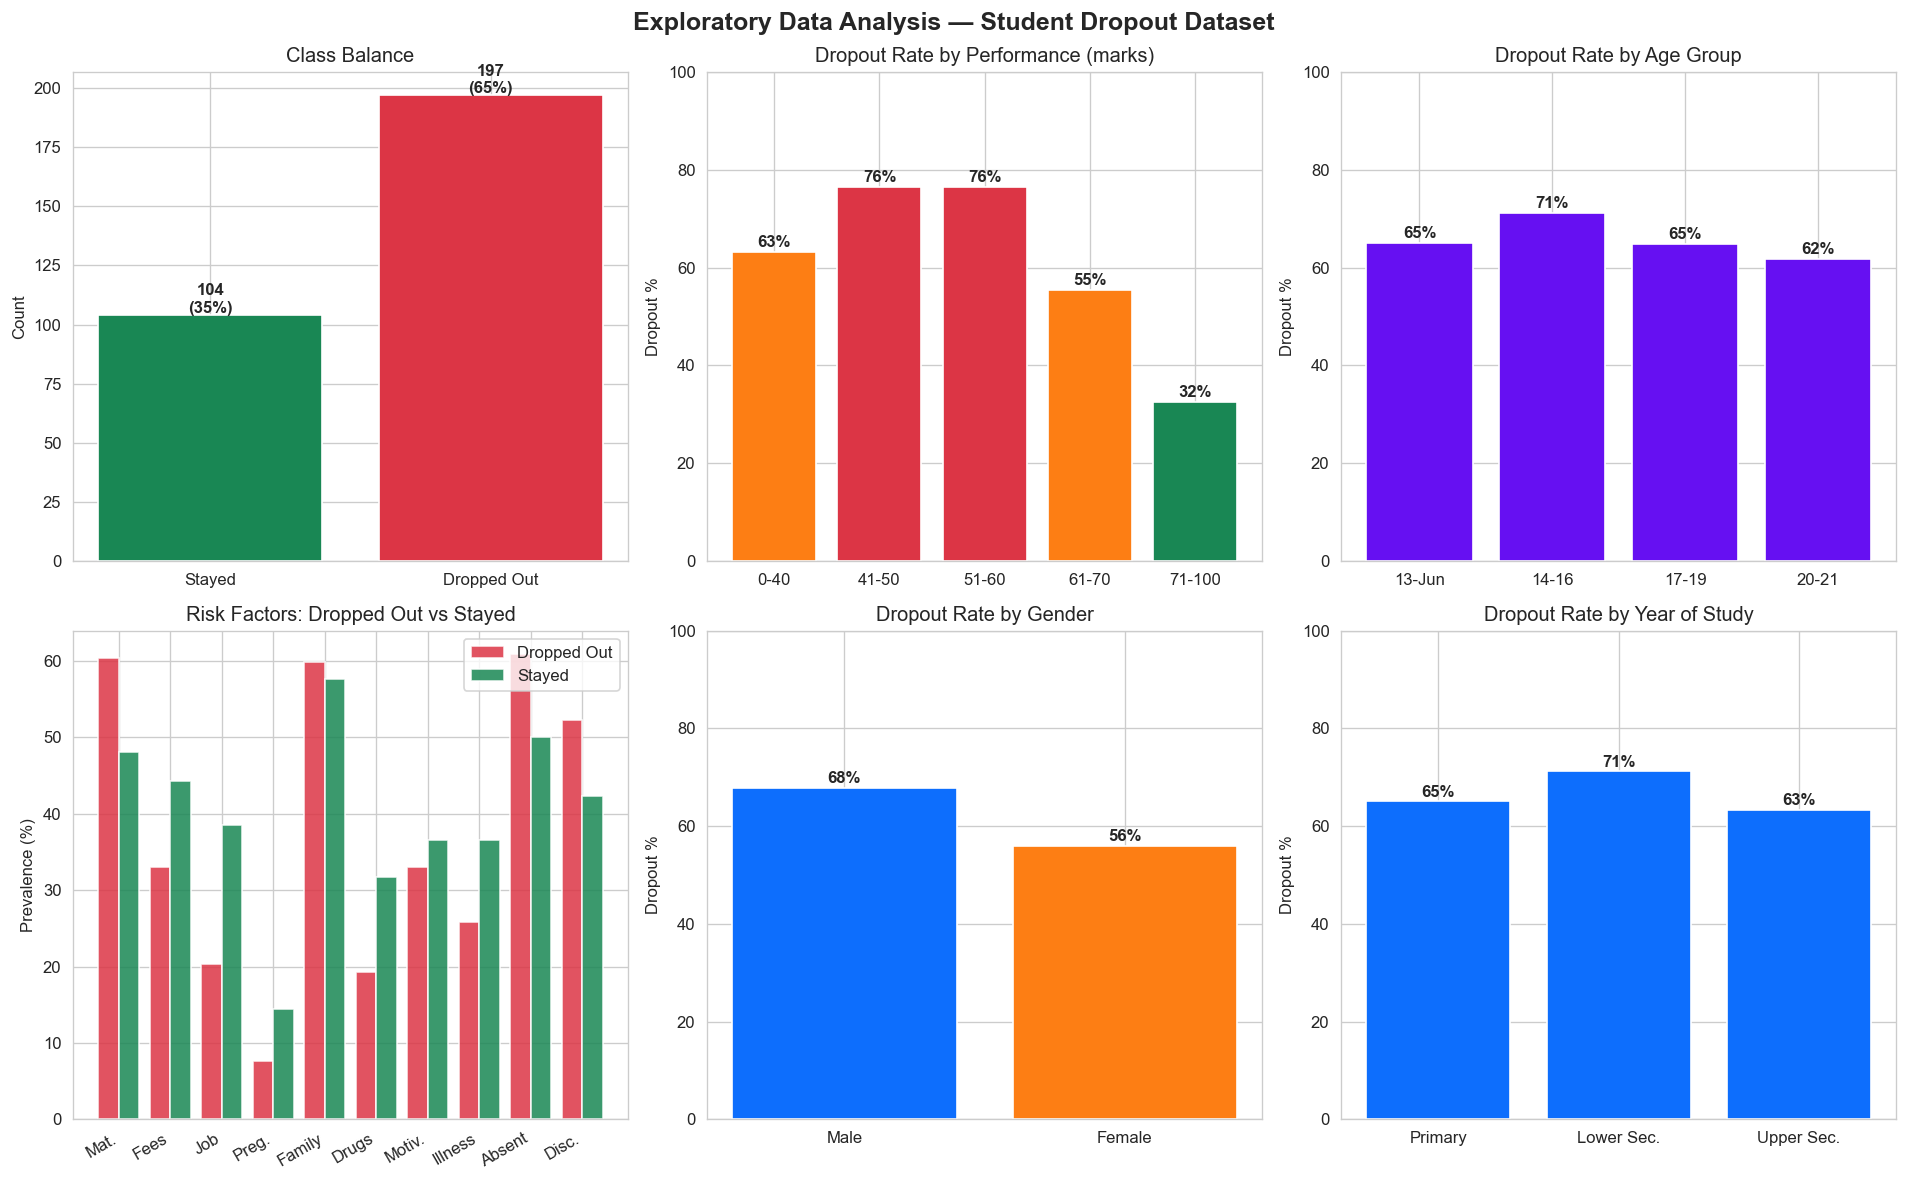

✅ Saved: eda_charts.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Exploratory Data Analysis — Student Dropout Dataset",
             fontsize=15, fontweight='bold')

# Chart 1: Class Balance
ax = axes[0, 0]
vals  = df['Dropped_out'].value_counts().sort_index()
bars  = ax.bar(['Stayed', 'Dropped Out'], vals.values,
               color=['#198754', '#dc3545'], edgecolor='white')
for b, v in zip(bars, vals.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
            f'{v}\n({v/len(df)*100:.0f}%)', ha='center', fontweight='bold')
ax.set_title('Class Balance')
ax.set_ylabel('Count')

# Chart 2: Dropout Rate by Performance
ax = axes[0, 1]
rate = df.groupby('Performance')['Dropped_out'].mean() * 100
clrs = ['#dc3545' if v > 65 else '#fd7e14' if v > 50 else '#198754'
        for v in rate.values]
ax.bar(['0-40','41-50','51-60','61-70','71-100'], rate.values,
       color=clrs, edgecolor='white')
for i, v in enumerate(rate.values):
    ax.text(i, v+1, f'{v:.0f}%', ha='center', fontweight='bold')
ax.set_title('Dropout Rate by Performance (marks)')
ax.set_ylabel('Dropout %')
ax.set_ylim(0, 100)

# Chart 3: Dropout Rate by Age Group
ax = axes[0, 2]
rate = df.groupby('Child_Age')['Dropped_out'].mean() * 100
ax.bar(['13-Jun','14-16','17-19','20-21'], rate.values,
       color='#6610f2', edgecolor='white')
for i, v in enumerate(rate.values):
    ax.text(i, v+1, f'{v:.0f}%', ha='center', fontweight='bold')
ax.set_title('Dropout Rate by Age Group')
ax.set_ylabel('Dropout %')
ax.set_ylim(0, 100)

# Chart 4: Risk Factors Comparison
ax = axes[1, 0]
risk_cols   = ['Lack_of_School_Material','Lack_of_School_Fees',
               'Job_opportunity','Pregnancy','Family_conflicts',
               'Drug_abuse','Lack_of_motivation','Illness',
               'Absenteism','Bad_Discipline']
short_names = ['Mat.','Fees','Job','Preg.','Family',
               'Drugs','Motiv.','Illness','Absent','Disc.']
dr = df[df['Dropped_out']==1][risk_cols].mean() * 100
sr = df[df['Dropped_out']==0][risk_cols].mean() * 100
x  = np.arange(len(short_names)); w = 0.4
ax.bar(x-w/2, dr.values, w, label='Dropped Out', color='#dc3545', alpha=0.85)
ax.bar(x+w/2, sr.values, w, label='Stayed',      color='#198754', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=30, ha='right')
ax.set_title('Risk Factors: Dropped Out vs Stayed')
ax.set_ylabel('Prevalence (%)')
ax.legend()

# Chart 5: Dropout by Gender
ax = axes[1, 1]
rate = df.groupby('Child_Gender')['Dropped_out'].mean() * 100
ax.bar(['Male','Female'], rate.values,
       color=['#0d6efd','#fd7e14'], edgecolor='white')
for i, v in enumerate(rate.values):
    ax.text(i, v+1, f'{v:.0f}%', ha='center', fontweight='bold')
ax.set_title('Dropout Rate by Gender')
ax.set_ylabel('Dropout %')
ax.set_ylim(0, 100)

# Chart 6: Dropout by Year of Study
ax = axes[1, 2]
rate = df.groupby('Year_of_Study')['Dropped_out'].mean() * 100
ax.bar(['Primary','Lower Sec.','Upper Sec.'], rate.values,
       color='#0d6efd', edgecolor='white')
for i, v in enumerate(rate.values):
    ax.text(i, v+1, f'{v:.0f}%', ha='center', fontweight='bold')
ax.set_title('Dropout Rate by Year of Study')
ax.set_ylabel('Dropout %')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_charts.png")

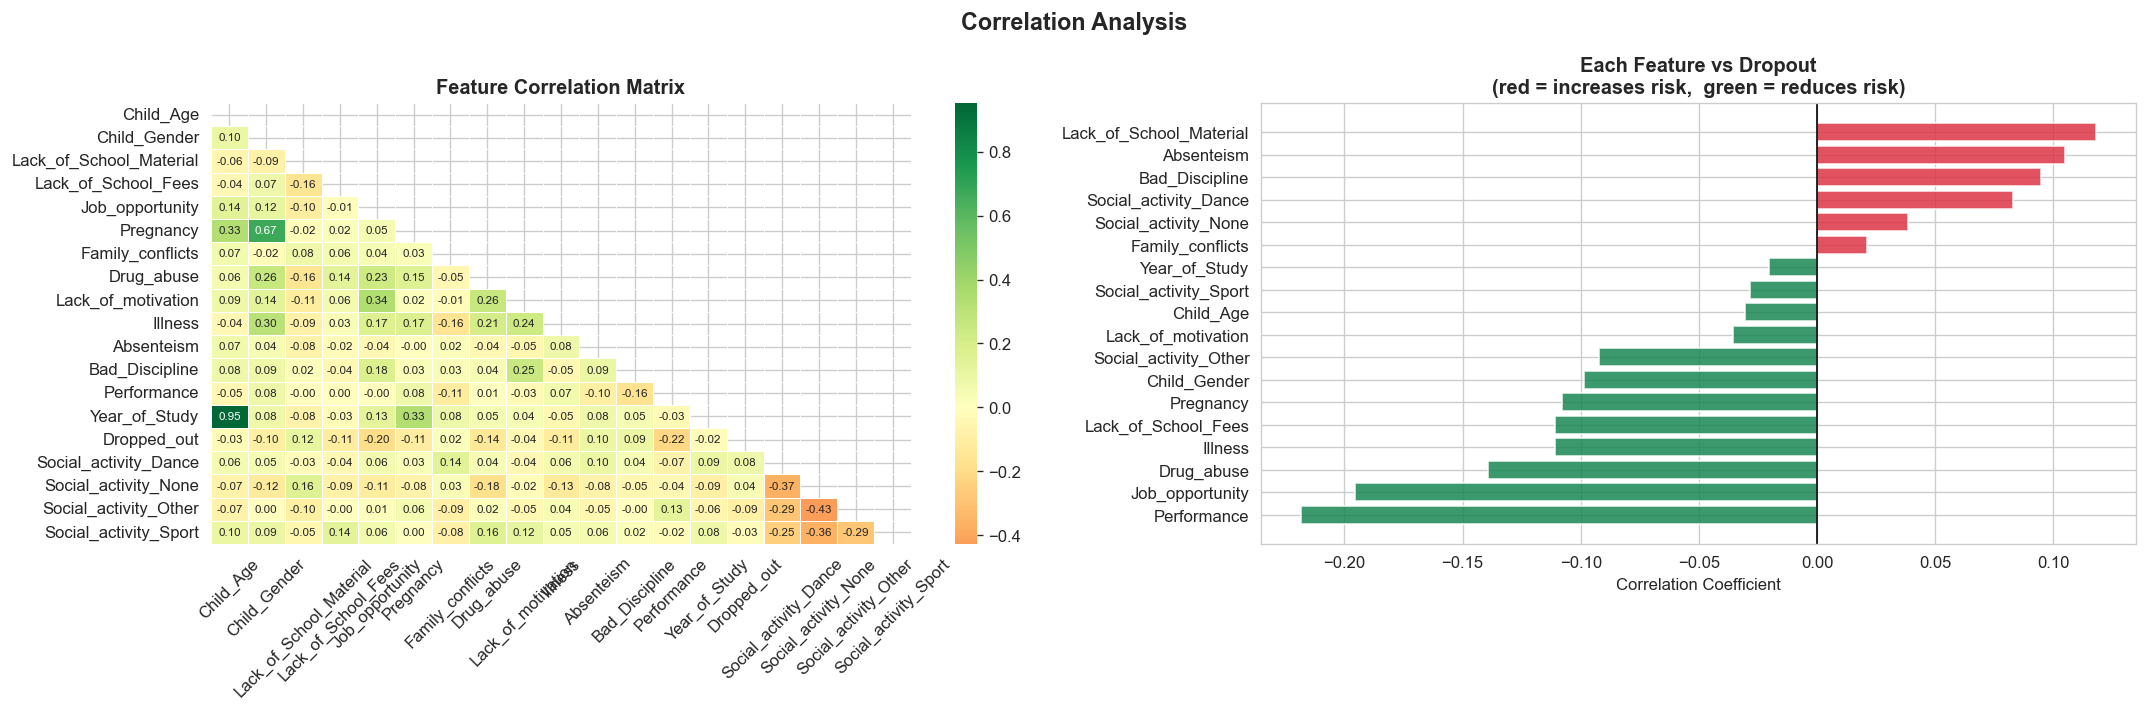

✅ Saved: heatmap.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Correlation Analysis", fontsize=14, fontweight='bold')

# --- Chart 1: Full correlation heatmap ---
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.3,
    annot_kws={'size': 7},
    ax=axes[0]
)
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# --- Chart 2: Correlation with Dropped_out only ---
corr_target = (
    df.corr()['Dropped_out']
    .drop('Dropped_out')
    .sort_values()
)
colors = ['#198754' if v < 0 else '#dc3545' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title(
    'Each Feature vs Dropout\n(red = increases risk,  green = reduces risk)',
    fontweight='bold'
)
axes[1].set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: heatmap.png")

In [8]:
def augment_data(df_original, multiplier=3, seed=42):
    """
    Makes 3 copies of every row, each slightly different.
    Result = original 301 rows + 903 new rows = 1204 total.
    Then duplicates are removed → final clean dataset.
    The Dropped_out column is NEVER changed.
    """
    np.random.seed(seed)

    binary_cols = [
        'Lack_of_School_Material', 'Lack_of_School_Fees', 'Job_opportunity',
        'Pregnancy', 'Family_conflicts', 'Drug_abuse', 'Lack_of_motivation',
        'Illness', 'Absenteism', 'Bad_Discipline'
    ]
    ordinal_cols = {
        'Child_Age':     (0, 3),
        'Child_Gender':  (0, 1),
        'Performance':   (0, 4),
        'Year_of_Study': (0, 2),
    }
    social_cols = [
        'Social_activity_Dance', 'Social_activity_None',
        'Social_activity_Other', 'Social_activity_Sport'
    ]

    new_rows = []

    for _, row in df_original.iterrows():
        for _ in range(multiplier):
            r    = row.copy()
            pick = np.random.rand()

            if pick < 0.50:
                # Flip one binary column (0 becomes 1, or 1 becomes 0)
                col    = np.random.choice(binary_cols)
                r[col] = 1 - r[col]

            elif pick < 0.75:
                # Move one ordinal column up or down by 1 step
                col    = np.random.choice(list(ordinal_cols.keys()))
                lo, hi = ordinal_cols[col]
                r[col] = int(np.clip(
                    int(r[col]) + np.random.choice([-1, 1]),
                    lo, hi
                ))

            else:
                # Change social activity to a different one
                new_soc = np.random.choice(social_cols)
                for sc in social_cols:
                    r[sc] = 1 if sc == new_soc else 0

            new_rows.append(r)

    df_new    = pd.DataFrame(new_rows, columns=df_original.columns)
    df_result = pd.concat([df_original, df_new], ignore_index=True)
    return df_result


# --- Run augmentation ---
print(f"Original rows : {len(df)}")

df_aug = augment_data(df, multiplier=3, seed=42)
print(f"After augment : {len(df_aug)}")

df_aug = df_aug.drop_duplicates().reset_index(drop=True)
print(f"After cleaning: {len(df_aug)}  (duplicates removed)")

# --- Checks ---
print(f"\nNull values : {df_aug.isnull().sum().sum()}  ← must be 0")
print(f"Duplicates  : {df_aug.duplicated().sum()}  ← must be 0")

print(f"\nClass balance:")
print(f"  Stayed      (0): {(df_aug['Dropped_out']==0).sum()}")
print(f"  Dropped Out (1): {(df_aug['Dropped_out']==1).sum()}")

# --- Save CSV so you can open and inspect it anytime ---
df_aug.to_csv('dropout_augmented_clean.csv', index=False)
print(f"\n✅ Saved: dropout_augmented_clean.csv")
print(f"   Open it in Excel to inspect the data anytime")

Original rows : 301
After augment : 1204
After cleaning: 983  (duplicates removed)

Null values : 0  ← must be 0
Duplicates  : 0  ← must be 0

Class balance:
  Stayed      (0): 347
  Dropped Out (1): 636

✅ Saved: dropout_augmented_clean.csv
   Open it in Excel to inspect the data anytime


In [9]:
# Features (X) = everything except Dropped_out
# Target   (y) = Dropped_out column only

X = df_aug.drop('Dropped_out', axis=1)
y = df_aug['Dropped_out']

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features — needed only for Logistic Regression
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training rows : {len(X_train)}")
print(f"Testing rows  : {len(X_test)}")

Training rows : 786
Testing rows  : 197


In [19]:
# Model 1: Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("✅ Random Forest :trained")

# Model 2: Decision Tree
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)
print("✅ Decision Tree :trained")

# Model 3: Logistic Regression (uses scaled data)
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    C=1.0
)
lr.fit(X_train_sc, y_train)
print("✅ Logistic Regression :trained")

✅ Random Forest :trained
✅ Decision Tree :trained
✅ Logistic Regression :trained


In [11]:
models = {
    'Random Forest':       (rf, X_test),
    'Decision Tree':       (dt, X_test),
    'Logistic Regression': (lr, X_test_sc),
}

results = {}

print(f"\n{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("=" * 65)

for name, (model, Xte) in models.items():
    yp    = model.predict(Xte)
    yprob = model.predict_proba(Xte)[:, 1]

    results[name] = {
        'accuracy' : accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp),
        'recall'   : recall_score(y_test, yp),
        'f1'       : f1_score(y_test, yp),
        'auc'      : roc_auc_score(y_test, yprob),
        'yp'       : yp,
        'yprob'    : yprob
    }
    r = results[name]
    print(f"{name:<22} {r['accuracy']:>9.3f} {r['precision']:>10.3f} "
          f"{r['recall']:>8.3f} {r['f1']:>8.3f} {r['auc']:>8.3f}")

print("=" * 65)

best = max(results, key=lambda k: results[k]['f1'])
print(f"\n🏆 Best model : {best}")
print(f"   Accuracy   : {results[best]['accuracy']:.3f}")
print(f"   F1 Score   : {results[best]['f1']:.3f}")
print(f"   ROC-AUC    : {results[best]['auc']:.3f}")


Model                   Accuracy  Precision   Recall       F1      AUC
Random Forest              0.853      0.883    0.890    0.886    0.930
Decision Tree              0.797      0.860    0.819    0.839    0.865
Logistic Regression        0.660      0.794    0.638    0.707    0.711

🏆 Best model : Random Forest
   Accuracy   : 0.853
   F1 Score   : 0.886
   ROC-AUC    : 0.930


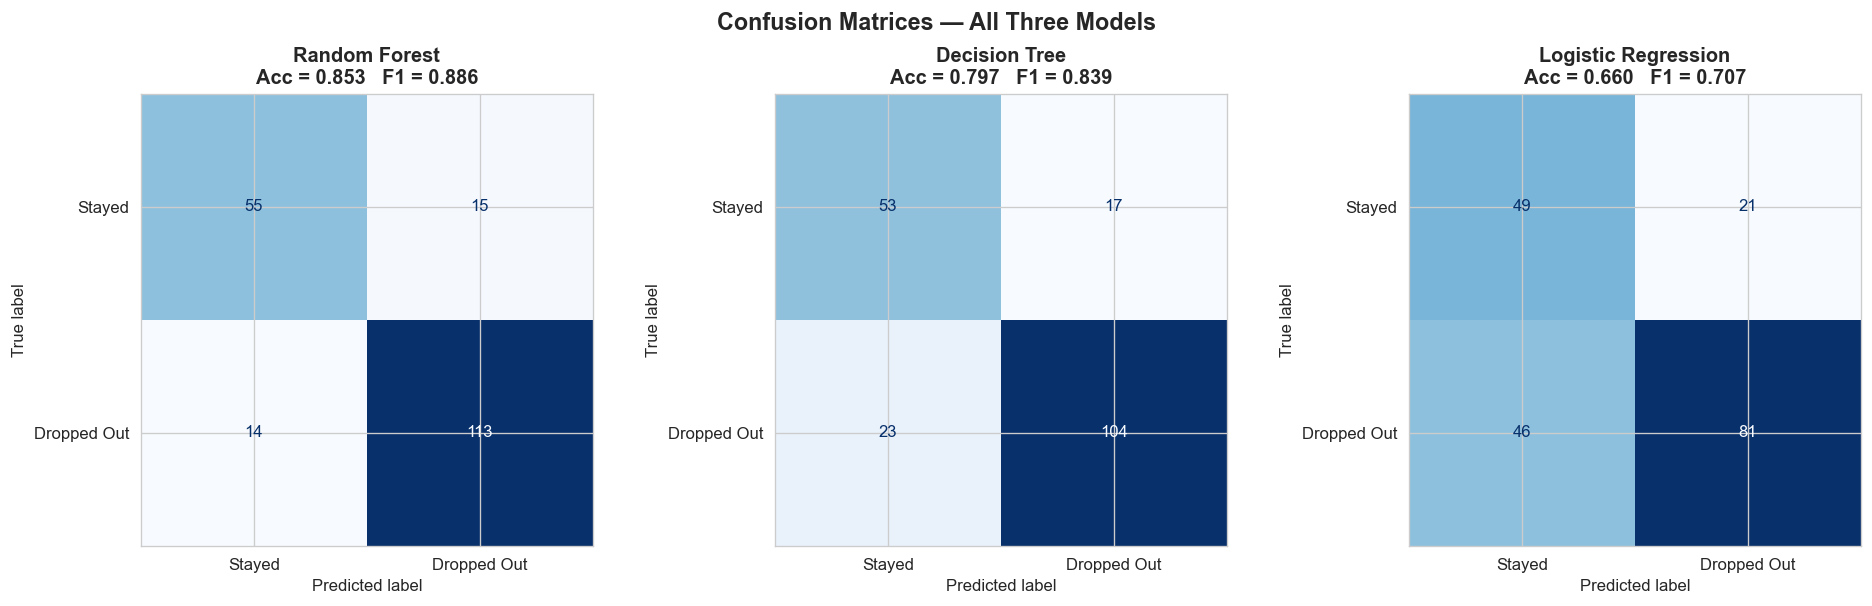

✅ Saved: confusion_matrices.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Confusion Matrices — All Three Models",
             fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, res['yp']),
        display_labels=['Stayed', 'Dropped Out']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(
        f"{name}\nAcc = {res['accuracy']:.3f}   F1 = {res['f1']:.3f}",
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrices.png")

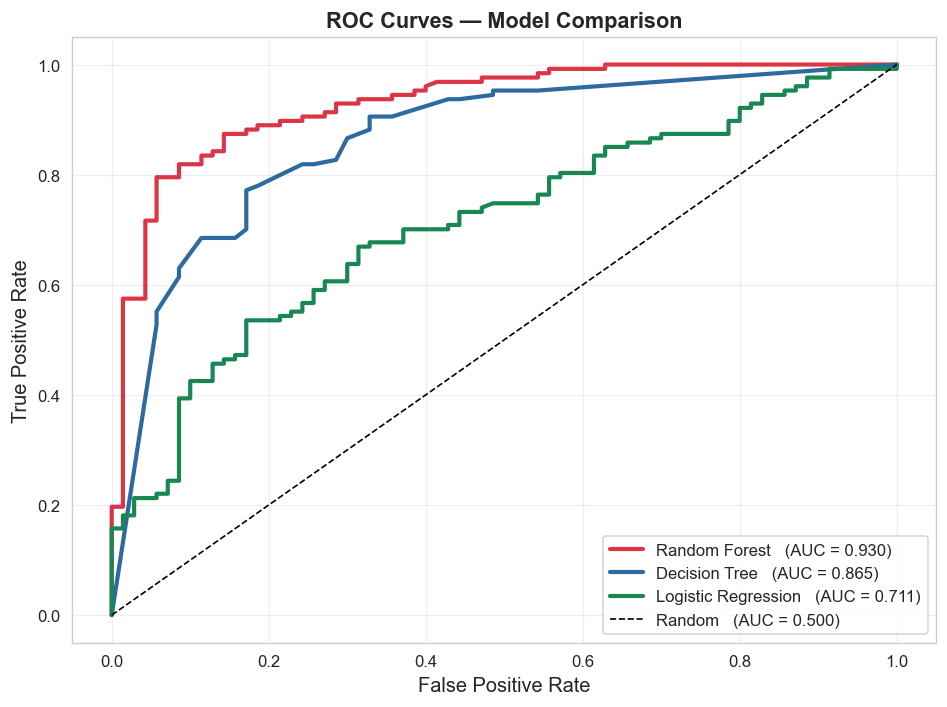

✅ Saved: roc_curves.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ['#dc3545', '#2d6a9f', '#198754']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['yprob'])
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f"{name}   (AUC = {res['auc']:.3f})")

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random   (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: roc_curves.png")

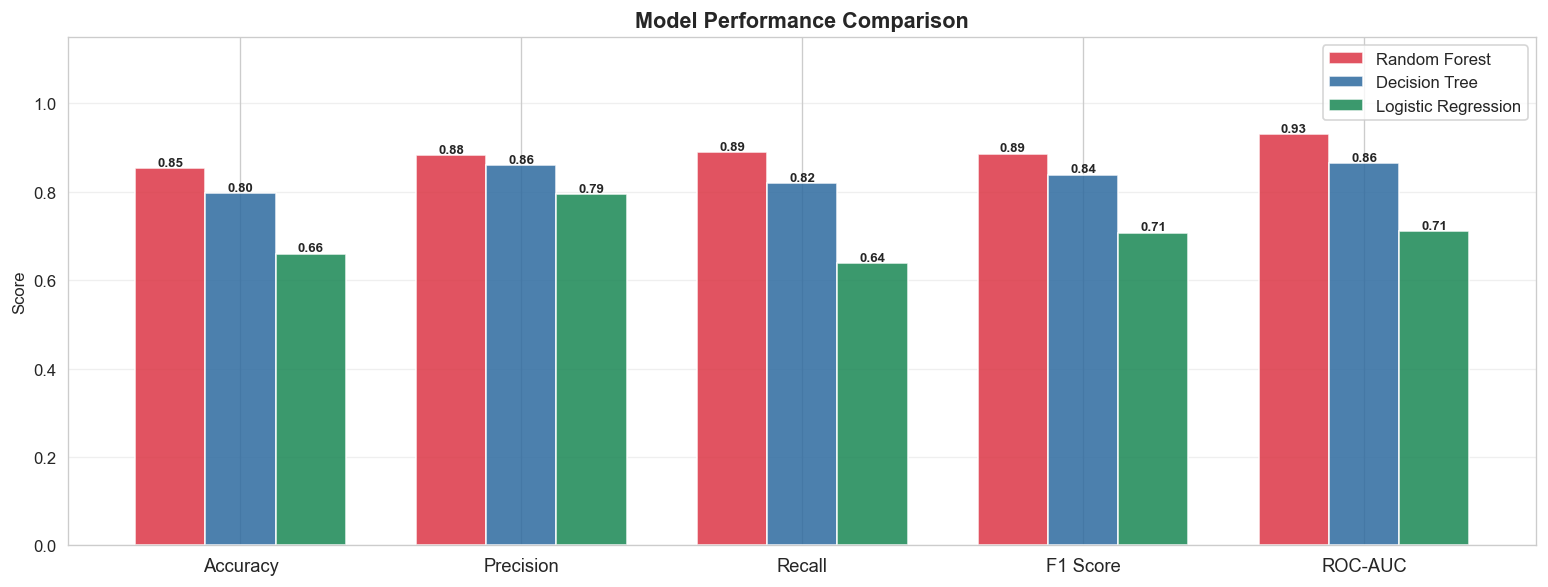

✅ Saved: model_comparison.png


In [14]:
metrics       = ['accuracy', 'precision', 'recall', 'f1', 'auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
colors_bar    = ['#dc3545', '#2d6a9f', '#198754']
x = np.arange(len(metrics))
w = 0.25

fig, ax = plt.subplots(figsize=(13, 5))

for i, (name, color) in enumerate(zip(results.keys(), colors_bar)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*w - w, vals, w, label=name, color=color, alpha=0.85)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: model_comparison.png")

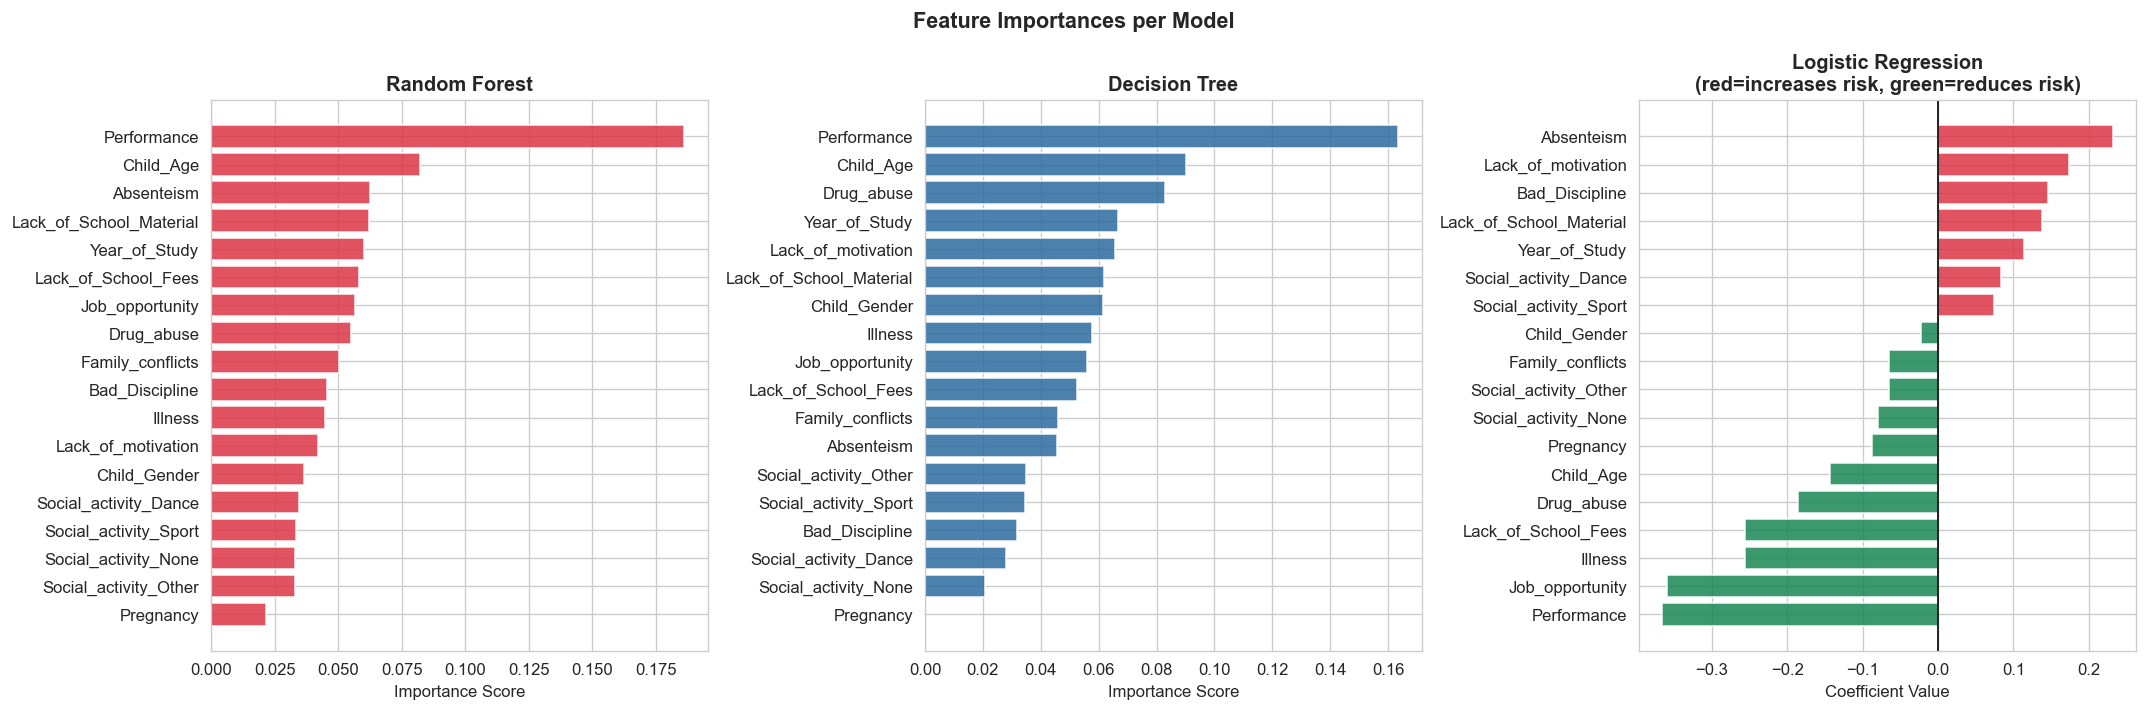

✅ Saved: feature_importance.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Feature Importances per Model", fontsize=13, fontweight='bold')

feat_names = X.columns.tolist()

# Random Forest
rf_imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values()
axes[0].barh(rf_imp.index, rf_imp.values, color='#dc3545', alpha=0.85)
axes[0].set_title('Random Forest', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Decision Tree
dt_imp = pd.Series(dt.feature_importances_, index=feat_names).sort_values()
axes[1].barh(dt_imp.index, dt_imp.values, color='#2d6a9f', alpha=0.85)
axes[1].set_title('Decision Tree', fontweight='bold')
axes[1].set_xlabel('Importance Score')

# Logistic Regression
lr_coef = pd.Series(lr.coef_[0], index=feat_names).sort_values()
clrs    = ['#dc3545' if v > 0 else '#198754' for v in lr_coef.values]
axes[2].barh(lr_coef.index, lr_coef.values, color=clrs, alpha=0.85)
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set_title('Logistic Regression\n(red=increases risk, green=reduces risk)',
                  fontweight='bold')
axes[2].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance.png")

In [18]:
model_objects = {
    'Random Forest':       rf,
    'Decision Tree':       dt,
    'Logistic Regression': lr,
}

# Save best model
joblib.dump(model_objects[best], 'best_dropout_model.pkl')

# Verify it works
loaded = joblib.load('best_dropout_model.pkl')
Xcheck = X_test_sc if best == 'Logistic Regression' else X_test

print(f"✅ Saved: best_dropout_model.pkl")
print(f"   Model    : {best}")
print(f"   Accuracy : {accuracy_score(y_test, loaded.predict(Xcheck)):.3f}")

✅ Saved: best_dropout_model.pkl
   Model    : Random Forest
   Accuracy : 0.853
